# 6.27 Quantum Information: Gates, Circuits, Teleportation, and Algorithms

<!-- This single H1 (one per notebook, "# <number> <Title>") is the page's
     title: it sets the sidebar entry, breadcrumb, browser tab, and search
     result. The branded banner below is generated by the shared `ecp`
     package, so the look of every notebook in the series lives in one place. -->

In [1]:
from ecp.style import header, use_style

use_style()  # apply the series Matplotlib style
header(
    volume="Volume VI — Quantum Mechanics",
    number="6.27",
    title="Quantum Information: Gates, Circuits, Teleportation, and Algorithms",
    blurb="The volume's last idea is its first one, grown up: a quantum computer "
    "is the linear algebra we have done all along, used on purpose. Qubits are the "
    "two-state system of the opening movement, gates are unitary matrices, "
    "circuits are their products, and measurement is the Born rule. From these and "
    "from entanglement come teleportation, the no-cloning theorem, and algorithms "
    "that outrun any classical machine. We build every one from scratch — and show "
    "that the software the field uses is only a shorthand for the matrices in our "
    "hands.",
    difficulty="advanced",
    estimate="240–300 min",
)

<ECP header: 2879 chars of HTML>

## Notebook overview

This is the capstone of Volume VI, and its argument is a single realization:
**a quantum computer is nothing more than the linear algebra this volume has been
doing all along.** A qubit is the two-state system of Movement I ([§6.4](stern-gerlach-qubit.ipynb), [§6.8](bloch-sphere-entanglement.ipynb)); a
quantum **gate** is a unitary matrix (the evolution of [§6.7](time-evolution.ipynb)); a quantum **circuit**
is a product of gates acting on a tensor-product state ([§6.14](angular-momentum-algebra.ipynb), [§6.8](bloch-sphere-entanglement.ipynb)); a
**measurement** is the Born rule ([§6.5](postulates.ipynb)). Nothing new is required — only these
pieces, arranged deliberately.

From them, and from **entanglement as a resource** ([§6.25](bell-inequality.ipynb), [§6.26](density-matrix.ipynb)), come feats with
no classical analogue. **Quantum teleportation** transfers an unknown qubit across
space using only a shared Bell pair and two classical bits — reproducing the input
exactly, for every measurement outcome, without ever cloning it (the **no-cloning
theorem**, itself a one-line consequence of linearity). **Quantum algorithms** turn
superposition and interference into speed: **Deutsch–Jozsa** decides a global
property of a function in a *single* query where classical computation may need
exponentially many; **Grover's** search finds a marked item among $N$ in about
$\tfrac\pi4\sqrt N$ steps by amplitude amplification — a rotation in a 2-D
subspace, the same geometry we have used throughout. **Shor's** algorithm (named,
not built) would factor large integers efficiently, breaking the cryptography that
secures the internet — the reason quantum computing commands the attention it
does. And the density matrix and entropy of [§6.26](density-matrix.ipynb) are exactly the tools that
quantify the entanglement these protocols spend and the decoherence that quantum
error correction must fight.

We build every runnable, validated result **from scratch in NumPy** — gates as
unitary matrices, circuits as `@` products of `numpy.kron` tensor factors,
measurement by Born-rule sampling. The professional software (Qiskit) appears only
as an illustration, explicitly fenced so it never enters the numerical spine.

> **The Qiskit fence.** The runnable, validated core is entirely from-scratch
> NumPy. Qiskit appears once, in a *display-only* cell (an import guarded so it
> cannot fail the build), purely to show that the industry notation is a shorthand
> for the matrices we build by hand: `H` is the Hadamard gate, `cx` is our CNOT,
> `numpy.kron` is the tensor product. The physics is the linear algebra, not the
> library.

> **Method specificity.** Gates are unitary matrices; multi-qubit gates and states
> use `numpy.kron`; controlled gates are built from projectors $P_0\otimes I+P_1
> \otimes U$; circuits are `@` products; measurement is Born-rule sampling with
> `numpy.random.default_rng`.

## Theory in brief

### The qubit and the state of many qubits

A **qubit** is a normalized vector in $\mathbb C^2$ ([§6.4](stern-gerlach-qubit.ipynb), [§6.8](bloch-sphere-entanglement.ipynb)). $n$ qubits live in
the tensor product $(\mathbb C^2)^{\otimes n}$ of dimension $2^n$ (`numpy.kron`);
that exponential growth is the root of quantum computing's power — and of the cost
of simulating it classically.

```{math}
:label: eq-qi-qubit
|\psi\rangle \in \mathbb C^2 , \qquad
|\Psi\rangle \in (\mathbb C^2)^{\otimes n}\cong\mathbb C^{2^n} .
```

### Quantum gates as unitaries

A gate is a **unitary** matrix (norm-preserving, so probability is conserved — the
evolution of [§6.7](time-evolution.ipynb)). Single-qubit: the Paulis $X,Y,Z$ ([§6.6](pauli-uncertainty.ipynb)), the **Hadamard** $H$
(which makes superposition, $H|0\rangle=(|0\rangle+|1\rangle)/\sqrt2$), the phase
gates $S,T$. Multi-qubit: the **CNOT**, built from projectors,

```{math}
:label: eq-gates
\mathrm{CNOT} = P_0\otimes I + P_1\otimes X , \qquad P_0=|0\rangle\langle0|,\ P_1=|1\rangle\langle1| ,
```

which flips the target iff the control is $|1\rangle$; controlled-$U$ and the
Toffoli generalize it. A small set (e.g. $H,T,\mathrm{CNOT}$) is **universal** —
it approximates any unitary (named, not proved).

### Quantum circuits and measurement

A circuit is a **product** of unitary matrices (read right to left), gates on
disjoint qubits combined by tensor product ($I$ on untouched wires):

```{math}
:label: eq-circuits
|\Psi_{\text{out}}\rangle = U_k\cdots U_2 U_1\,|\Psi_{\text{in}}\rangle .
```

The **Bell state** is three symbols: from $|00\rangle$, apply $H$ to qubit 0, then
$\mathrm{CNOT}(0,1)$, giving $(|00\rangle+|11\rangle)/\sqrt2$ (the [§6.8](bloch-sphere-entanglement.ipynb) Bell state).
Measurement is the Born rule ([§6.5](postulates.ipynb)): outcome probabilities are squared amplitudes,
and repeated runs are Born-rule sampling ([§6.4](stern-gerlach-qubit.ipynb)).

### The no-cloning theorem

No unitary copies an arbitrary unknown qubit:

```{math}
:label: eq-no-cloning
\nexists\,U:\ U|\psi\rangle|0\rangle=|\psi\rangle|\psi\rangle\ \ \forall|\psi\rangle ,
```

a one-line consequence of **linearity** — a cloner that works on $|0\rangle$ and
$|1\rangle$ fails on their superposition. This is why quantum information cannot be
copied, why teleportation must *move* rather than copy, and why eavesdropping is
detectable.

### Quantum teleportation

Alice holds an unknown $|\psi\rangle$ and shares a Bell pair with Bob. She applies
$\mathrm{CNOT}$ then $H$ to her two qubits, **measures** them (two classical bits),
and sends the bits to Bob, who applies a Pauli correction to recover $|\psi\rangle$
exactly:

```{math}
:label: eq-teleportation
\text{bits }(m_0,m_1)\ \longrightarrow\ \text{Bob applies } Z^{m_0}X^{m_1}:\quad
I,\ X,\ Z,\ ZX .
```

No clone is made (Alice's copy is destroyed by measurement), nothing travels
faster than light (Bob needs the bits), yet the unknown state is transferred —
entanglement plus classical communication as a channel. Its dual, **superdense
coding** ({eq}`eq-superdense`), sends two classical bits by transmitting one qubit
of a shared pair.

```{math}
:label: eq-superdense
\text{teleportation: 1 ebit}+2\ \text{cbits}\to1\ \text{qubit};\quad
\text{superdense: 1 ebit}+1\ \text{qubit}\to2\ \text{cbits.}
```

### Quantum parallelism, and two algorithms

A unitary applied to a superposition acts on all basis states "at once"
(parallelism), but a measurement returns only one — so the art of a quantum
algorithm is to arrange **interference** that concentrates amplitude on the answer.

```{math}
:label: eq-parallelism
U\Big(\tfrac1{\sqrt{2^n}}\textstyle\sum_x|x\rangle\Big)
= \tfrac1{\sqrt{2^n}}\textstyle\sum_x U|x\rangle .
```

**Deutsch–Jozsa** ({eq}`eq-deutsch-jozsa`): given $f$ promised constant or
balanced, a superposition of all inputs, the oracle (a phase kickback), and a
second layer of Hadamards make the all-zeros outcome certain **iff** $f$ is
constant — one query where classical needs up to $2^{n-1}+1$.

```{math}
:label: eq-deutsch-jozsa
H^{\otimes n}\,U_f\,H^{\otimes n}|0\rangle^{\otimes n}:\quad
P(0\cdots0)=1\ \text{iff } f \text{ constant.}
```

**Grover** ({eq}`eq-grover`): to find a marked item among $N=2^n$, each iteration
applies the **oracle** (sign-flip the marked amplitude) then the **diffuser**
(reflection about the mean), which together **rotate** the state toward the marked
item in the 2-D marked/unmarked plane. After $\sim\tfrac\pi4\sqrt N$ iterations the
amplitude concentrates on the answer.

```{math}
:label: eq-grover
(\text{diffuser})(\text{oracle})\ \text{iterated}\ \sim\tfrac\pi4\sqrt N\ \text{times};
\quad \text{classical needs } \sim N/2 .
```

### Shor, error correction, and why this matters

**Shor's** algorithm ({eq}`eq-shor`) factors an $n$-bit integer in polynomial time
by using the quantum Fourier transform to find a period — breaking RSA. Its number
theory is a horizon; its significance is the punchline. And **decoherence** ([§6.26](density-matrix.ipynb))
is the central obstacle, so real machines need **quantum error correction** —
encoding one logical qubit in many physical ones — the entanglement and entropy of
[§6.26](density-matrix.ipynb) being exactly its tools.

```{math}
:label: eq-shor
\text{Shor: factor } n\text{-bit } N \text{ in } \mathrm{poly}(n);\qquad
\text{QEC fights decoherence (6.26).}
```

```{math}
:label: eq-qec-connection
S(\rho_A)\ \text{(6.26) measures the entanglement resource; decoherence spends it.}
```

- Reference: Nielsen & Chuang {cite}`nielsen_chuang` (the standard text — gates,
  circuits, teleportation, Deutsch–Jozsa, Grover, Shor); Griffiths
  {cite}`griffiths_qm`; Preskill's lecture notes. Cross-reference [§6.4](stern-gerlach-qubit.ipynb)/[§6.8](bloch-sphere-entanglement.ipynb) (the
  qubit, the Bloch sphere, the Bell state, Born-rule sampling), [§6.5](postulates.ipynb) (measurement),
  [§6.6](pauli-uncertainty.ipynb) (Pauli operators), [§6.7](time-evolution.ipynb) (unitary evolution), [§6.14](angular-momentum-algebra.ipynb) (tensor products), [§6.25](bell-inequality.ipynb)
  (Bell nonlocality — the resource certified), [§6.26](density-matrix.ipynb) (density matrix, entropy,
  decoherence), and — as the volume's closer — [§6.1](complex-vector-spaces.ipynb)–[§6.3](dirac-notation-spectral-decomposition.ipynb) (the linear-algebra arsenal
  now revealed as the machinery of quantum computation), forward to Volume VII.
  Named as horizons: Shor's algorithm, quantum error correction, physical qubit
  implementations, the universality proofs.

---
## Setup

Everything runnable is from-scratch NumPy. The data are the conventions and the gate
alphabet: qubit 0 is the leftmost (most-significant) tensor factor, so an $n$-qubit state
is a length-$2^n$ vector indexed by the integer $b_0b_1\cdots b_{n-1}$; circuits are `@`
products read right to left; and the fixed specimens every circuit below is written in
terms of are the single-qubit matrices $I,X,Y,Z,H,S,T$, the projectors $P_0=|0\rangle
\langle0|$ and $P_1=|1\rangle\langle1|$ they get combined with, and the computational-basis
kets $|0\rangle,|1\rangle$. The instruments are the register plumbing and the meters:
`kron_list` folds `numpy.kron` over a list, `single(U, q, nq)` pads a one-qubit gate with
identities on the untouched wires ($I\otimes\cdots\otimes U\otimes\cdots\otimes I$),
`basis_state` assembles a basis ket from a bit string, `is_unitary` is the admission test
$U^\dagger U=I$, and `born_probabilities`/`sample_measurements` read outcome statistics off
a state vector by the Born rule of [§6.5](postulates.ipynb) and the `numpy.random.default_rng`
sampling of [§6.4](stern-gerlach-qubit.ipynb). The multi-qubit construction this notebook is
named for is deliberately absent: you write the projector sum `controlled` and its
two-control generalization `toffoli` in Exercise 2, and every circuit, protocol and
algorithm after that is assembled in the exercise that needs it.

The Setup below holds this notebook's data and instruments — nothing you
are asked to build. It is collapsed so the building stays yours; expand it
whenever you want the details.

<!-- setup-policy: v2 -->

In [2]:
import numpy as np
import matplotlib.pyplot as plt

from ecp import draw, validate

# data: the single-qubit gate alphabet {eq}`eq-gates` — the fixed unitary matrices, the
# projectors P0, P1 they are combined into controlled gates with, and the basis kets
I2 = np.eye(2, dtype=complex)
X = np.array([[0, 1], [1, 0]], dtype=complex)
Y = np.array([[0, -1j], [1j, 0]], dtype=complex)
Z = np.array([[1, 0], [0, -1]], dtype=complex)
H = np.array([[1, 1], [1, -1]], dtype=complex) / np.sqrt(2)
S = np.array([[1, 0], [0, 1j]], dtype=complex)
T = np.array([[1, 0], [0, np.exp(1j * np.pi / 4)]], dtype=complex)
P0 = np.array([[1, 0], [0, 0]], dtype=complex)  # |0⟩⟨0|
P1 = np.array([[0, 0], [0, 1]], dtype=complex)  # |1⟩⟨1|
KET0 = np.array([1, 0], dtype=complex)
KET1 = np.array([0, 1], dtype=complex)


# instrument: `numpy.kron` folded over a list — the register plumbing every embedding is
# written with. What the tensor product *builds* is the lesson; the fold itself is not.
def kron_list(ops):
    r"""Tensor product of a list of matrices/vectors (`numpy.kron` folded)."""
    out = ops[0]
    for op in ops[1:]:
        out = np.kron(out, op)
    return out


# instrument: identity padding on the untouched wires. Which wire a gate acts on is
# bookkeeping; the multi-qubit construction that *is* this notebook's lesson — the projector
# sum of a controlled gate — is written by the reader in Exercise 2.
def single(U, q, nq):
    r"""Embed a single-qubit gate ``U`` on qubit ``q`` of an ``nq``-qubit register.

    Builds $I\otimes\cdots\otimes U\otimes\cdots\otimes I$ with `numpy.kron`.
    """
    return kron_list([U if k == q else I2 for k in range(nq)])


# instrument: squared amplitudes. The Born rule itself is the lesson of §6.5; here it is
# only the meter that reads outcome statistics off a state vector.
def born_probabilities(state):
    r"""Outcome probabilities $|\langle x|\Psi\rangle|^2$ (the Born rule, §6.5)."""
    return np.abs(state) ** 2


# instrument: the same meter at finite shots — one `numpy.random.Generator.choice` call, the
# sampling of §6.4 restated so the exercises can report counts the way a device does.
def sample_measurements(state, shots, rng):
    r"""Born-rule sampling of computational-basis outcomes with `numpy.random.default_rng` (§6.4)."""
    probs = born_probabilities(state)
    return rng.choice(len(state), size=shots, p=probs / probs.sum())


# instrument: the admission test every gate must pass, one `numpy.allclose`. The exercises put
# under test *which* matrices are unitary, not how the comparison is formed.
def is_unitary(U):
    r"""Check $U^\dagger U = I$."""
    return np.allclose(U.conj().T @ U, np.eye(len(U)))


# instrument: input assembly. A computational-basis ket for the truth tables and circuit
# inputs below — a `numpy.kron` chain of $|0\rangle$s and $|1\rangle$s, not a method.
def basis_state(bits):
    r"""Computational basis ket $|b_0 b_1\cdots\rangle$ from a bit string/list."""
    return kron_list([KET0 if b in (0, "0") else KET1 for b in bits])

## Exercise 1 — Single-qubit gates as unitaries

A quantum gate is nothing more exotic than a unitary matrix, and the single-qubit alphabet
fits on one line each: the Paulis $X,Y,Z$ — the observables of [§6.6](pauli-uncertainty.ipynb),
now read as operations rather than as questions — the **Hadamard** $H$, and the phase gates
$S=\mathrm{diag}(1,i)$ and $T=\mathrm{diag}(1,e^{i\pi/4})$ that rotate about the polar axis
by a quarter and an eighth turn. Unitarity, $U^\dagger U=I$, is the only admission
requirement quantum mechanics imposes: it is what keeps the total probability at one, and it
is why a gate is the same object as the time evolution of [§6.7](time-evolution.ipynb),
packaged into a single step. Two identities fix the Hadamard's character —
$H|0\rangle=(|0\rangle+|1\rangle)/\sqrt2$, so it manufactures superposition from a definite
state, and $H^2=I$, so applying it twice undoes it.

1. Take the matrices `X`, `Y`, `Z`, `H`, `S`, `T` from the setup and collect them by name.
2. Verify each is unitary ($U^\dagger U=I$) with the setup's `is_unitary`.
3. Show $H|0\rangle=(|0\rangle+|1\rangle)/\sqrt2$ and $H^2=I$.
4. Note the Paulis are the [§6.6](pauli-uncertainty.ipynb) observables and that gates are the unitary
   evolution of [§6.7](time-evolution.ipynb), packaged.

Cite {eq}`eq-qi-qubit`, {eq}`eq-gates`.

In [3]:
# (solution hidden on the public site)


  X: unitary = True
  Y: unitary = True
  Z: unitary = True
  H: unitary = True
  S: unitary = True
  T: unitary = True
H|0⟩ = [0.7071+0.j 0.7071+0.j]   = (|0⟩+|1⟩)/√2: True
H² = I: True


### Validation 1

Every gate must be unitary, and the Hadamard must create an equal superposition
from $|0\rangle$ (with $H^2=I$): quantum gates are unitary matrices.

In [4]:
validate.check(
    all(is_unitary(G) for G in gates.values())
    and np.allclose(H @ KET0, (KET0 + KET1) / np.sqrt(2))
    and np.allclose(H @ H, I2),
    "quantum gates are unitary matrices; H creates an equal superposition",
)

✓  quantum gates are unitary matrices; H creates an equal superposition


True

## Exercise 2 — Multi-qubit gates and the CNOT

One gate separates a quantum computer from a pile of independent qubits: a **controlled**
gate, which acts on one wire only when another wire says so. Its matrix is written with the
projectors $P_0=|0\rangle\langle0|$ and $P_1=|1\rangle\langle1|$, which resolve the control
qubit into its two branches — the target is left alone in the $|0\rangle$ branch and acted on
by $U$ in the $|1\rangle$ branch — so the whole gate is the two-term sum $P_0\otimes I+P_1
\otimes U$ {eq}`eq-gates`. On a register of $n_q$ qubits each term is a `numpy.kron` chain
carrying the projector on the control wire, $I$ or $U$ on the target, and $I$ on every wire
that is neither, which is what makes one expression valid for any control/target pair. With
$U=X$ this is the **CNOT**, classical XOR made reversible: $|00\rangle\to|00\rangle$,
$|01\rangle\to|01\rangle$, $|10\rangle\to|11\rangle$, $|11\rangle\to|10\rangle$. A second
control gives the **Toffoli** (CCX), a sum over the four combinations $(P_0\text{ or }P_1)$
on one control and $(P_0\text{ or }P_1)$ on the other, with $X$ on the target in exactly the
one term where both controls are $|1\rangle$. The Toffoli is universal for classical
reversible logic — which is how ordinary computation embeds inside unitary evolution.

1. Write `controlled(U, ctrl, tgt, nq)`, returning the two-term projector sum above embedded
   on an `nq`-qubit register (identities on every other wire), and form the CNOT as
   `controlled(X, ctrl=0, tgt=1, nq=2)`. **Write this one yourself** — the implementation is
   the lesson.
2. Verify it is unitary.
3. Confirm the truth table: $\mathrm{CNOT}|00\rangle=|00\rangle$, $\mathrm{CNOT}
   |10\rangle=|11\rangle$, and so on.
4. Write `toffoli(c1, c2, tgt, nq)` as the four-term sum described above, and check that it
   flips the target on $|110\rangle$ and is unitary. **Write this one yourself** — the
   implementation is the lesson.

Cite {eq}`eq-gates`.

In [5]:
# (solution hidden on the public site)


CNOT unitary: True
  CNOT|00⟩ = |00⟩
  CNOT|01⟩ = |01⟩
  CNOT|10⟩ = |11⟩
  CNOT|11⟩ = |10⟩
Toffoli|110⟩ = |111⟩ (flips target iff both controls are 1); unitary: True


### Validation 2

The CNOT must be unitary and flip the target iff the control is $|1\rangle$
($|00\rangle\to|00\rangle$, $|10\rangle\to|11\rangle$): controlled gates entangle
qubits.

In [6]:
validate.check(
    is_unitary(CNOT)
    and np.allclose(CNOT @ basis_state("00"), basis_state("00"))
    and np.allclose(CNOT @ basis_state("10"), basis_state("11"))
    and is_unitary(TOFF),
    "CNOT is unitary and flips the target iff the control is |1⟩ (controlled gates entangle)",
)

✓  CNOT is unitary and flips the target iff the control is |1⟩ (controlled gates entangle)


True

## Exercise 3 — Circuits and the Bell state

A circuit is a **product** of unitary matrices {eq}`eq-circuits`, and because a matrix acts
on the vector to its right the product is read right to left: the gate applied first stands
last. Three symbols are then enough for the most famous state in the subject. Starting from
$|00\rangle$, a Hadamard on qubit 0 — embedded as $H\otimes I$, since qubit 1 is untouched —
gives $(|00\rangle+|10\rangle)/\sqrt2$; a CNOT controlled by qubit 0 flips qubit 1 in the
second term only, and the result is $(|00\rangle+|11\rangle)/\sqrt2$. That is the Bell state
of [§6.8](bloch-sphere-entanglement.ipynb), whose random marginals and perfect correlations
the volume has already met — here manufactured to order by $\mathrm{CNOT}\,(H\otimes I)$.

1. Start from $|00\rangle$ with the setup's `basis_state`.
2. Apply $H$ to qubit 0, embedded as $H\otimes I$ by the setup's `single`.
3. Apply the `controlled` CNOT you wrote in Exercise 2.
4. Confirm the output is $(|00\rangle+|11\rangle)/\sqrt2$ — the Bell state of [§6.8](bloch-sphere-entanglement.ipynb).

Cite {eq}`eq-circuits`.

In [7]:
# (solution hidden on the public site)


Bell circuit output: [0.7071 0.     0.     0.7071]
matches §6.8 Bell state: True


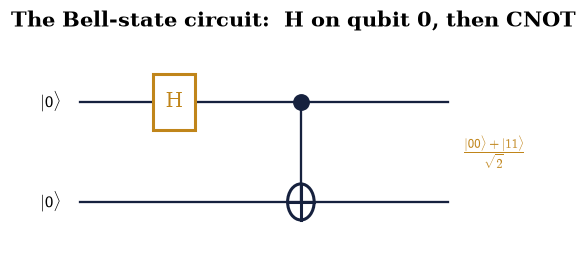

In [8]:
# (solution hidden on the public site)


### Validation 3

The $H+\mathrm{CNOT}$ circuit must prepare exactly the Bell state $(|00\rangle+
|11\rangle)/\sqrt2$ of [§6.8](bloch-sphere-entanglement.ipynb).

In [9]:
validate.close(
    bell_out, bell_ref, "the H + CNOT circuit prepares the §6.8 Bell state", rtol=1e-9
)

✓  the H + CNOT circuit prepares the §6.8 Bell state   [max|Δ| = 0 (rtol=1e-09, atol=1e-09)]


True

## Exercise 4 — Measurement and Born sampling

A state vector is not what a machine reports. What comes back from a real device is a list of
shots, each one an outcome drawn at random with the Born probability
$|\langle x|\Psi\rangle|^2$ ([§6.5](postulates.ipynb)), and the distribution has to be
reconstructed from the counts ([§6.4](stern-gerlach-qubit.ipynb)). For the Bell state
$(|00\rangle+|11\rangle)/\sqrt2$ the exact probabilities are $\tfrac12$ on $00$, $\tfrac12$ on
$11$, and zero on $01$ and $10$: the two qubits are perfectly correlated, so measuring one
fixes the other — the very correlation the Bell test of [§6.25](bell-inequality.ipynb) turned
into a violated inequality. Five thousand shots from a `numpy.random.default_rng(2718)`
generator are enough to see it, sampling noise included.

1. Compute the outcome probabilities as squared amplitudes with the setup's
   `born_probabilities` ([§6.5](postulates.ipynb)).
2. Sample 5000 shots with the setup's `sample_measurements` and a seeded
   `numpy.random.default_rng` ([§6.4](stern-gerlach-qubit.ipynb)).
3. Histogram the outcomes.
4. Confirm only $00$ and $11$ appear, each about half the time (perfect
   correlation).

Cite {eq}`eq-circuits`.

In [10]:
# (solution hidden on the public site)


Born probabilities: [0.5 0.  0.  0.5]
  00:  2508  (50.2%)
  01:     0  (0.0%)
  10:     0  (0.0%)
  11:  2492  (49.8%)


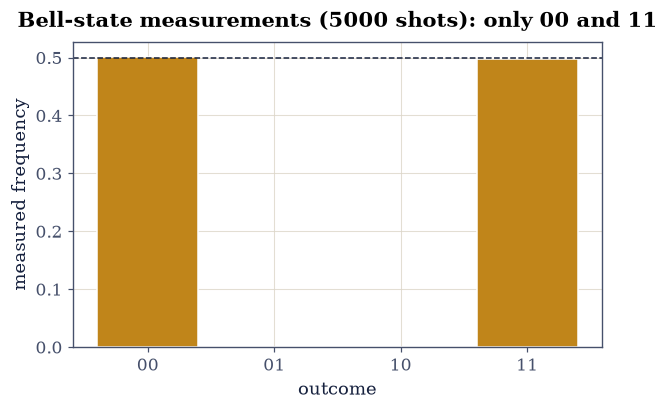

In [11]:
# (solution hidden on the public site)


### Validation 4

Sampled Bell-state measurements must give only $00$ and $11$, each near 50% — the
Born rule in action.

In [12]:
validate.check(
    counts[1] == 0 and counts[2] == 0 and abs(counts[0] - counts[3]) < 0.1 * shots,
    "sampled Bell measurements give only 00 and 11 with equal frequency (Born rule)",
)

✓  sampled Bell measurements give only 00 and 11 with equal frequency (Born rule)


True

## Exercise 5 — The no-cloning theorem

No unitary copies an arbitrary unknown qubit {eq}`eq-no-cloning`, and the obstruction is not
dynamical but a single line of **linearity**. Suppose some $U$ cloned, so that
$U|\psi\rangle|0\rangle=|\psi\rangle|\psi\rangle$ for every $|\psi\rangle$. Demanding it on
the two basis states fixes $U|00\rangle=|00\rangle$ and $U|10\rangle=|11\rangle$ — which is
exactly the CNOT of Exercise 2. Linearity then leaves no freedom on a superposition: feeding
it $|+\rangle|0\rangle$ with $|+\rangle=(|0\rangle+|1\rangle)/\sqrt2$ must give
$(|00\rangle+|11\rangle)/\sqrt2$, the *entangled* Bell state, whereas a genuine clone would
have to produce the *product* $|+\rangle|+\rangle$. The two are different vectors, so no such
$U$ exists. This is why quantum information cannot be duplicated, why teleportation has to
move a state rather than copy it, and why an eavesdropper cannot listen undetected.

1. Build the hypothetical basis cloner as the CNOT you wrote in Exercise 2 — the unitary
   that does copy $|0\rangle$ and $|1\rangle$.
2. Apply it to $|+\rangle|0\rangle$.
3. Compare the result with the product $|+\rangle|+\rangle$ a true clone would give.
4. Conclude cloning is impossible — the reason teleportation must move, not copy.

Cite {eq}`eq-no-cloning`.

In [13]:
# (solution hidden on the public site)


cloner on |+⟩|0⟩ = [0.707 0.    0.    0.707]
a true clone |+⟩|+⟩ = [0.5 0.5 0.5 0.5]
equal? False  → cloning the superposition FAILS


### Validation 5

A hypothetical cloner fixed to copy $|0\rangle$ and $|1\rangle$ must fail on their
superposition ($(|00\rangle+|11\rangle)/\sqrt2\ne|+\rangle|+\rangle$): unknown
quantum states cannot be cloned.

In [14]:
validate.check(
    not np.allclose(got, want),
    "a cloner consistent on |0⟩,|1⟩ fails on their superposition — unknown states cannot be cloned",
)

✓  a cloner consistent on |0⟩,|1⟩ fails on their superposition — unknown states cannot be cloned


True

## Exercise 6 — Quantum teleportation

Alice holds one qubit in an unknown state $|\psi\rangle$ and shares a Bell pair with Bob, who
is far away; the three qubits together are the vector $|\psi\rangle\otimes(|00\rangle+
|11\rangle)/\sqrt2$ in $\mathbb C^8$. Alice applies $\mathrm{CNOT}(0,1)$ and then $H$ on
qubit 0, which rewrites that vector as a sum of four equally weighted branches, one for each
value of the two bits she is about to read. Measuring her two qubits selects a branch — the
projector $P_{m_0}\otimes P_{m_1}\otimes I$, renormalized — and in each branch Bob's qubit is
$|\psi\rangle$ up to one Pauli, so the two classical bits $(m_0,m_1)$ tell him which of
$I,X,Z,ZX$ to undo: $Z^{m_0}X^{m_1}$ {eq}`eq-teleportation`. The fidelity
$|\langle\psi|\text{Bob}\rangle|^2$ is then exactly 1 for every outcome, each occurring with
probability $\tfrac14$. Nothing is cloned — Alice's copy is destroyed by her measurement,
consistent with Exercise 5 — and nothing outruns light, because without the two bits Bob's
qubit is maximally mixed. The specimen state is $|\psi\rangle=\cos(0.7)|0\rangle+
e^{1.1i}\sin(0.7)|1\rangle$, chosen complex so that a real-valued accident cannot flatter us.

1. Write `teleport(psi)`: form the three-qubit state, apply Alice's $\mathrm{CNOT}(0,1)$ and
   $H(0)$ with your Exercise 2 `controlled` and the setup's `single`, project onto each of the
   four outcomes $(m_0,m_1)$ and renormalize, read off Bob's qubit, apply the correction
   $Z^{m_0}X^{m_1}$, and return the branch probability, the fidelity and the correction's name
   for each outcome. **Write this one yourself** — the implementation is the lesson.
2. Run it on the unknown $|\psi\rangle$ above.
3. Confirm the fidelity is 1 for all four outcomes, with the corrections $I,X,Z,ZX$ and
   probability $\tfrac14$ each.
4. Note what the protocol spends: one entangled pair and two classical bits per qubit sent.

Cite {eq}`eq-teleportation`.

In [15]:
# (solution hidden on the public site)


  outcome (0,0): prob=0.250  correction=II  fidelity=1.000000
  outcome (0,1): prob=0.250  correction=IX  fidelity=1.000000
  outcome (1,0): prob=0.250  correction=ZI  fidelity=1.000000
  outcome (1,1): prob=0.250  correction=ZX  fidelity=1.000000
teleportation recovers the unknown state exactly for all four outcomes


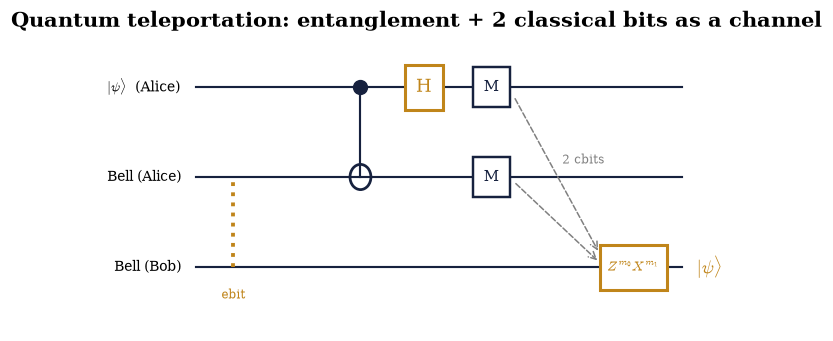

In [16]:
# (solution hidden on the public site)


### Validation 6

The teleported state must match the input with fidelity 1 for all four measurement
outcomes, using the corrections $I,X,Z,ZX$: teleportation transfers an unknown
qubit via one Bell pair and two classical bits.

In [17]:
validate.check(
    all(abs(fid - 1.0) < 1e-9 for _, fid, _ in tel.values())
    and {corr for _, _, corr in tel.values()} == {"II", "IX", "ZI", "ZX"},
    "teleportation transfers an unknown qubit exactly for all outcomes (corrections I/X/Z/ZX)",
)

✓  teleportation transfers an unknown qubit exactly for all outcomes (corrections I/X/Z/ZX)


True

## Exercise 7 — Deutsch–Jozsa

A function $f:\{0,1\}^n\to\{0,1\}$ is promised to be either **constant** or **balanced**
(equal to 0 on exactly half its inputs). Classically the promise is worth little: in the
worst case one must evaluate $f$ on $2^{n-1}+1$ inputs before the answer is certain. One
quantum query settles it {eq}`eq-deutsch-jozsa`. The oracle is the reversible embedding
$U_f:|x\rangle|y\rangle\to|x\rangle|y\oplus f(x)\rangle$, a permutation matrix with a single
1 in each column, and it is queried on a superposition of *all* inputs
{eq}`eq-parallelism`. Preparing the ancilla in $|1\rangle$ before the Hadamards puts it in
$(|0\rangle-|1\rangle)/\sqrt2$, an eigenvector of the XOR, so the oracle's action shows up as
a **phase kickback** $(-1)^{f(x)}$ on the input register instead of a change in the ancilla.
A constant $f$ contributes a global sign that a second layer of Hadamards folds back onto
$|0\cdots0\rangle$ with certainty; a balanced $f$ makes those phases cancel there exactly, so
the all-zeros amplitude vanishes. The answer is therefore not "a value of $f$" but a global
property of it, read off in one shot. Four oracles on $n=3$ make the test: $f\equiv0$ and
$f\equiv1$ (constant), and the parity of $x$ and its lowest bit (balanced).

1. Write `deutsch_jozsa(f, n)`: build $U_f$ on $n+1$ qubits, prepare
   $|0\rangle^{\otimes n}|1\rangle$, apply Hadamards to every qubit, apply $U_f$, apply
   Hadamards to the input register, and return `"constant"` or `"balanced"` from the
   probability of an all-zeros input register. **Write this one yourself** — the
   implementation is the lesson.
2. Run it on the two constant and the two balanced oracles above.
3. Confirm the verdict is right in every case, from a single oracle query.
4. Compare with the classical worst case, $2^{n-1}+1$ evaluations.

Cite {eq}`eq-parallelism`, {eq}`eq-deutsch-jozsa`.

In [18]:
# (solution hidden on the public site)


  f ≡ 0 (constant)         → constant  (expected constant)
  f ≡ 1 (constant)         → constant  (expected constant)
  parity (balanced)        → balanced  (expected balanced)
  first bit (balanced)     → balanced  (expected balanced)
one query decided each; classical worst case needs up to 2^(n-1)+1 = 5


### Validation 7

Deutsch–Jozsa must return 'constant' for the constant oracles and 'balanced' for
the balanced ones, each in a single query.

In [19]:
validate.check(
    dj_ok,
    "Deutsch–Jozsa decides the global property (constant vs balanced) with a single evaluation",
)

✓  Deutsch–Jozsa decides the global property (constant vs balanced) with a single evaluation


True

## Exercise 8 — Grover's search

Searching an unstructured list of $N=2^n$ items classically costs $\sim N/2$ queries; Grover's
algorithm needs about $\tfrac\pi4\sqrt N$ {eq}`eq-grover`, and the reason is geometry. Two
reflections make the iteration: the **oracle**, which flips the sign of the marked amplitude
alone (the identity with a single $-1$ on the diagonal), and the **diffuser**
$2|s\rangle\langle s|-I$, a reflection about the uniform state $|s\rangle=H^{\otimes n}
|0\rangle$ — equivalently, about the mean amplitude. A reflection followed by a reflection is
a **rotation**, and here it happens in the two-dimensional plane spanned by the marked state
and the uniform superposition of the rest, turning the state by a fixed angle $2\theta$ with
$\theta=\arcsin(1/\sqrt N)$ per iteration. Starting at angle $\theta$ from the unmarked axis,
the state reaches the marked axis after $(\pi/2-\theta)/2\theta\approx\tfrac\pi4\sqrt N$
steps. That the answer is a rotation carries a practical warning: keep iterating past the
optimum and the state rotates straight past the answer, so the success probability falls
again — visible if the $N=64$ case is run for 16 iterations instead of the optimal 6.

1. Write `grover(marked, n, n_iter=None)`: start from $|s\rangle$, apply the oracle then the
   diffuser `n_iter` times (defaulting to the exact optimum
   $\mathrm{round}\big((\pi/2-\theta)/2\theta\big)$), and return the final marked probability
   together with its history over the iterations. **Write this one yourself** — the
   implementation is the lesson.
2. Run it at the optimal iteration count for $n=2,\dots,8$ and confirm the marked
   probability is near 1 throughout.
3. Take the history for $N=64$ well past the optimum and see the overshoot.
4. Read each iteration as a rotation toward the marked state in the 2-D
   marked/unmarked plane.

Cite {eq}`eq-grover`.

In [20]:
# (solution hidden on the public site)


Grover success probability at the optimal iteration count:
  N =   4:  P(marked) = 1.0000  (~(π/4)√N iterations)
  N =   8:  P(marked) = 0.9453  (~(π/4)√N iterations)
  N =  16:  P(marked) = 0.9613  (~(π/4)√N iterations)
  N =  32:  P(marked) = 0.9992  (~(π/4)√N iterations)
  N =  64:  P(marked) = 0.9966  (~(π/4)√N iterations)
  N = 128:  P(marked) = 0.9956  (~(π/4)√N iterations)


  N = 256:  P(marked) = 0.9999  (~(π/4)√N iterations)


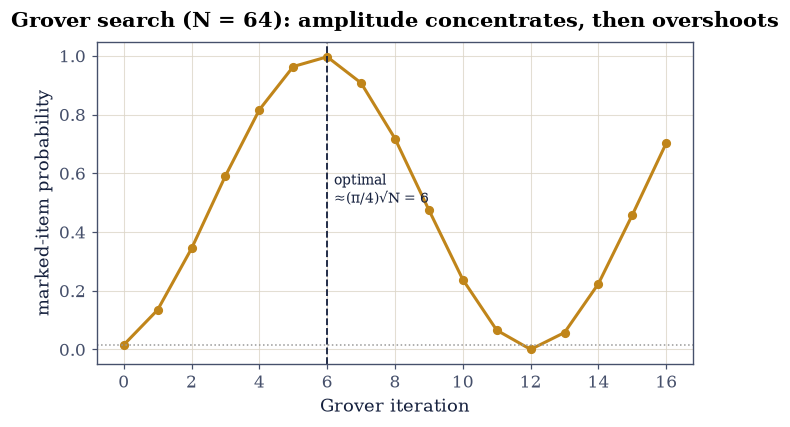

In [21]:
# (solution hidden on the public site)


### Validation 8

Grover must find the marked item with high probability in about $\tfrac\pi4\sqrt N$
iterations, for $N$ up to 256: amplitude amplification gives a quadratic speedup.

In [22]:
validate.check(
    min(grover_probs[N] for N in (8, 16, 32, 64, 128, 256)) > 0.9,
    "Grover finds the marked item with probability >0.9 in ~(π/4)√N iterations (N up to 256)",
)

✓  Grover finds the marked item with probability >0.9 in ~(π/4)√N iterations (N up to 256)


True

## Exercise 9 — The Qiskit fence: same circuit, professional notation *(student)*

The professional software the field runs on writes the Bell circuit in three lines, and it is
worth seeing exactly what those lines stand for. Qiskit's `qc.h(0)` is our $H\otimes I$ —
the setup's `single(H, 0, 2)`; its `qc.cx(0, 1)` is our CNOT, the projector sum
`controlled(X, 0, 1, 2)` of Exercise 2; and the tensor product that assembles a two-qubit
register is `numpy.kron`. The library is a notation, not a physics. To keep that claim
honest this notebook never lets it into the numerical spine: the Qiskit call below is
display-only and guarded, so an absent installation prints a message and changes nothing,
while the validated Bell state is the one the from-scratch matrices compute.

1. Read the Qiskit rendering of the Bell circuit below (it is *not* part of the
   validated computation).
2. Rebuild the same circuit from the matrices — `controlled(X, 0, 1, 2)` and
   `single(H, 0, 2)` on `basis_state("00")` — and compare it with the Exercise 3 result.
3. Note the correspondence: `h(0)` is our $H\otimes I$, `cx(0,1)` is our CNOT
   ($P_0\otimes I+P_1\otimes X$), and Qiskit's tensor product is `numpy.kron`.
4. Conclude that the library is a convenient notation; the physics is the linear
   algebra we already command.

Cite {eq}`eq-circuits`.

The Qiskit rendering (pin `qiskit~=2.0`), shown for reference only:

```python
from qiskit import QuantumCircuit          # display-only; not run in this build
qc = QuantumCircuit(2)
qc.h(0)                                    # our  single(H, 0, 2)
qc.cx(0, 1)                                # our  controlled(X, 0, 1, 2)
print(qc.draw())                           # the same H + CNOT circuit as Fig. 1
```

In [23]:
# (solution hidden on the public site)


Qiskit not installed — and it does not matter: the from-scratch NumPy
matrices above computed and validated the Bell state. Qiskit's h(0)/cx(0,1)
are exactly our single(H,0,2) and controlled(X,0,1,2). (pip install 'qiskit~=2.0')

from-scratch Bell state still correct: True


### Validation 9

The check depends only on the from-scratch NumPy: our matrices reproduce the Bell
circuit, confirming the professional tools are shorthand for the operations we
built here.

In [24]:
validate.close(
    bell_again,
    bell_ref,
    "the from-scratch matrix circuit reproduces the Bell state (the tools are shorthand for these operations)",
    rtol=1e-9,
)

✓  the from-scratch matrix circuit reproduces the Bell state (the tools are shorthand for these operations)   [max|Δ| = 0 (rtol=1e-09, atol=1e-09)]


True

## Exercise 10 — Entanglement as a resource: entropy across a protocol *(student / challenge)*

Entanglement is not a mood a state is in; it is a quantity that gets spent, and
[§6.26](density-matrix.ipynb) already supplies the meter. Trace one half out of the Bell pair
and what is left is the maximally mixed single-qubit state $\tfrac12 I$, whose von Neumann
entropy $-\sum_k\lambda_k\log_2\lambda_k$ is exactly 1 bit — one **ebit**, the standard unit
of the resource. Teleportation consumes one of them per qubit sent: after Alice's measurement
the pair is gone, and a second teleportation needs a second pair. Written as a ledger,
{eq}`eq-qec-connection` and {eq}`eq-superdense` say one ebit plus two classical bits buys the
transfer of one qubit, and the dual protocol spends one ebit plus one qubit to buy two
classical bits. The same ledger explains why real machines are hard: decoherence
([§6.26](density-matrix.ipynb)) leaks this resource to the environment for free, which is what
quantum error correction exists to fight.

1. Restate the [§6.26](density-matrix.ipynb) partial trace and von Neumann entropy as the two
   tools you need, and apply them to the Bell pair's density matrix.
2. Confirm the reduced state carries $S=1$ bit — one ebit.
3. Conclude teleportation costs exactly **one ebit** plus two classical bits per
   qubit sent.
4. Connect to decoherence ([§6.26](density-matrix.ipynb)): real devices leak this resource to the
   environment, which is why they need quantum error correction.

Cite {eq}`eq-qec-connection`.

In [25]:
# (solution hidden on the public site)


entanglement entropy of the shared Bell pair: S(ρ_A) = 1.000000 bit = 1 ebit
teleportation consumes exactly this one ebit (+ 2 classical bits) to send one qubit
decoherence (§6.26) leaks such entanglement to the environment — why QEC is needed


### Validation 10

The shared Bell pair must carry exactly one bit of entanglement entropy (one ebit)
— the resource teleportation spends, measured with the tools of [§6.26](density-matrix.ipynb).

In [26]:
validate.close(
    S_bell, 1.0, "teleportation consumes one bit of entanglement (one ebit)", atol=1e-6
)

✓  teleportation consumes one bit of entanglement (one ebit)   [got 1 vs expected 1 (rtol=1e-06, atol=1e-06)]


True

## Exercise 11 — A small algorithm, end to end *(challenge / stretch)*

Nothing new is needed for a complete computation — the pieces are all in hand, and the point
of this last exercise is that they compose. Take $n=3$, so $N=8$ items, and mark
$|101\rangle$, index 5 in the length-8 state vector. The uniform superposition is the start,
the optimal iteration count from Exercise 8 is
$\mathrm{round}\big((\pi/2-\theta)/2\theta\big)=2$ for $N=8$, and the final state is read the
way a device would report it: 4000 shots sampled from the Born distribution with a seeded
`numpy.random.default_rng`, not a probability printed off the amplitudes. If the marked item
dominates those counts, then a from-scratch NumPy toolkit — matrices, `numpy.kron`, `@` — has
just run a quantum algorithm end to end.

1. Choose $n=3$ ($N=8$) and the marked item $|101\rangle$ (index 5), and take the success
   probability from your Exercise 8 `grover`.
2. Rebuild the final state vector explicitly: uniform superposition, then the optimal
   number of oracle+diffuser iterations.
3. Sample 4000 shots of it with the setup's `sample_measurements` and a seeded
   `numpy.random.default_rng`.
4. Confirm the marked item dominates the measured counts — a working quantum
   algorithm assembled entirely from the toolkit.

In [27]:
# (solution hidden on the public site)


3-qubit Grover for |101⟩ (index 5): 2 iterations, P(marked) = 0.9453
most-sampled outcome: |101⟩ (95.1% of shots) — the marked item


### Validation 11

The assembled 3-qubit Grover circuit must return the marked item $|101\rangle$ as
its dominant measured outcome: the from-scratch toolkit composes into working
quantum algorithms.

In [28]:
validate.check(
    top == marked_item and counts8[marked_item] > 0.7 * 4000,
    "the assembled from-scratch algorithm solves its stated problem (Grover finds |101⟩)",
)

✓  the assembled from-scratch algorithm solves its stated problem (Grover finds |101⟩)


True

## Exercise 12 — (Synthesis) The volume, closed

The course began with a two-state system — an electron's spin, a single qubit —
and the modest claim that quantum mechanics is linear algebra. It ends here with
that same qubit, that same linear algebra, assembled into a machine that teleports
states it cannot copy and searches faster than any classical computer can. Nothing
new was needed. Gates are the unitary evolution we studied in Movement I ([§6.7](time-evolution.ipynb));
circuits are their products on the tensor-product spaces of [§6.14](angular-momentum-algebra.ipynb); measurement is
the Born rule of [§6.5](postulates.ipynb); entanglement is the correlation we measured in the Bell
tests of [§6.25](bell-inequality.ipynb) and quantified with the entropy of [§6.26](density-matrix.ipynb); and the professional
software is a shorthand for the matrices we built by hand. The arsenal of [§6.1](complex-vector-spaces.ipynb)–[§6.3](dirac-notation-spectral-decomposition.ipynb)
— vectors, inner products, Hermitian and unitary matrices, eigenvalues — turns out
to have been the machinery of quantum computation all along.

It is a strange and beautiful thing that the rules we inferred from spectral lines
and Stern–Gerlach beams describe a computer. We did not add anything to quantum
mechanics to get here; we only asked what it could do if we arranged the
interference on purpose. The answer — a machine that breaks codes and moves the
uncopyable — was hiding in the linear algebra from the first page. And the same
decoherence that made a superposition look classical ([§6.26](density-matrix.ipynb)) is the dragon that
quantum engineering must slay: every protocol here assumes coherence the real
world is always trying to take away, which is why quantum error correction, built
from the very entanglement and entropy we have used, is the central challenge of
the field.

**Volume VI is complete** — from the postulates to the atom, from the three faces
of approximation to the foundations, and now to the information the theory can
carry. Volume VII takes the density matrix we just used and gives it a
temperature, $\rho=e^{-\beta H}/Z$: quantum statistical mechanics, where the
quantum world meets the thermodynamic one, and the linear algebra of the very
small becomes the physics of the very many.

## Notebook summary

- **Gates and circuits** {eq}`eq-gates`, {eq}`eq-circuits`: single-qubit gates and
  the CNOT ($P_0\otimes I+P_1\otimes X$) are unitary matrices; circuits are their
  `@` products; the $H+\mathrm{CNOT}$ circuit prepares the [§6.8](bloch-sphere-entanglement.ipynb) Bell state.
- **Measurement** is Born-rule sampling (`numpy.random.default_rng`): the Bell
  state gives only 00 and 11.
- **No-cloning** {eq}`eq-no-cloning`: a one-line consequence of linearity — a basis
  cloner fails on superpositions.
- **Teleportation** {eq}`eq-teleportation`: an unknown qubit crosses space on one
  ebit + two classical bits, recovered exactly for all four outcomes (corrections
  $I/X/Z/ZX$).
- **Deutsch–Jozsa** {eq}`eq-deutsch-jozsa`: a global property in one query;
  **Grover** {eq}`eq-grover`: a marked item in $\sim\tfrac\pi4\sqrt N$ steps
  (verified to $N=256$), amplitude amplification as rotation.
- **The resource** {eq}`eq-qec-connection`: the Bell pair is one ebit (entropy 1
  bit, [§6.26](density-matrix.ipynb)); decoherence spends it, so real machines need error correction.
- **The Qiskit fence**: the industry tool is a notation for the from-scratch
  matrices; the physics is the linear algebra of [§6.1](complex-vector-spaces.ipynb)–[§6.3](dirac-notation-spectral-decomposition.ipynb).

> **What was built vs named.** *Built and validated from scratch:* gates, circuits,
> measurement, no-cloning, teleportation, Deutsch–Jozsa, Grover, the entanglement
> resource. *Named as horizons:* Shor's algorithm, quantum error-correcting codes,
> physical qubit implementations, the universality proofs.

## Outlook

- **Shor's algorithm** and the quantum Fourier transform; the threat to RSA and
  post-quantum cryptography (horizons).
- **Quantum error correction** and fault tolerance: encoding logical qubits to
  fight decoherence ([§6.26](density-matrix.ipynb)) — the central engineering challenge (a horizon).
- **Physical qubits**: superconducting circuits, trapped ions, spin qubits ([§6.18](spin-magnetic.ipynb)),
  photonics (horizons).
- **Quantum statistical mechanics**: the density matrix with a temperature,
  $\rho=e^{-\beta H}/Z$ (Volume VII).
- Cross-reference [§6.4](stern-gerlach-qubit.ipynb)/[§6.8](bloch-sphere-entanglement.ipynb) (qubit/Bell), [§6.5](postulates.ipynb) (measurement), [§6.6](pauli-uncertainty.ipynb) (Pauli), [§6.7](time-evolution.ipynb)
  (unitary evolution), [§6.25](bell-inequality.ipynb) (Bell nonlocality), [§6.26](density-matrix.ipynb) (density matrix / entropy /
  decoherence), [§6.1](complex-vector-spaces.ipynb)–[§6.3](dirac-notation-spectral-decomposition.ipynb) (the linear-algebra arsenal), forward to Volume VII.

### References

```{bibliography}
:filter: docname in docnames
```

In [29]:
from ecp.style import footer

footer()

<ECP header: 1221 chars of HTML>